# Session 3 — SciPy: adding a statistical layer

**Plan for today**
1. Cleaning, then fitting distributions
2. Hypothesis testing
3. Correlation & optimization
4. Finishing `EDAReport`: `test_normality`, `compare_groups`, `correlation_significance`, `generate_report()`
5. Mini-project: run the finished class on real data end-to-end

Today's dataset is the **Pima Indians Diabetes Dataset** (`diabetes.csv`) — 768 real, anonymized
patient records, with 8 diagnostic measurements and a binary `Outcome` (1 = tested positive for
diabetes, 0 = negative). Make sure `diabetes.csv` is in the same folder as this notebook.

**A running theme today**: real data rarely fits a textbook distribution perfectly, and formal
statistical tests are often stricter judges than a histogram "looks like." That's not a flaw in the
exercises — learning to read an *inconclusive* or *messy* result honestly is as important as reading
a clean one. This dataset in particular has a well-known real-world quirk we'll deal with directly
in the first exercise.


In [2]:
# Run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize

sns.set_theme(style="whitegrid")
np.random.seed(42)


## Setup — loading and cleaning the data

Load `diabetes.csv`. The columns are: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome` (1 = diabetic, 0 = not).


In [3]:
diabetes_raw = pd.read_csv("diabetes.csv")
print(diabetes_raw.shape)
diabetes_raw.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Exercise 0.1 (core) — The zeros that aren't really zeros
Take a look at the data and answer the usual questions:

1. How many rows and columns are there?
2. What are the column names?
3. What data type does each column have?
4. Are there missing values?

In [4]:
diabetes_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Now run the cell below and look closely at the minimum values. How do you interpret them?

In [5]:
print(
    diabetes_raw[
        ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
    ].describe()
)


          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   120.894531      69.105469      20.536458   79.799479   31.992578
std     31.972618      19.355807      15.952218  115.244002    7.884160
min      0.000000       0.000000       0.000000    0.000000    0.000000
25%     99.000000      62.000000       0.000000    0.000000   27.300000
50%    117.000000      72.000000      23.000000   30.500000   32.000000
75%    140.250000      80.000000      32.000000  127.250000   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


<details>
<summary>A blood pressure of <b>0</b>? A BMI of <b>0</b>? What does that mean?</summary>
Those aren't real measurements. They're <b>physically impossible</b>, which means they almost certainly represent <i>missing</i> data that got encoded as <code>0</code> instead of left blank. 

This is actually a well-documented data-quality issue of this specific dataset, a good reminder that "no missing values" (`.isna().sum()` on
`diabetes_raw` would show all zeros!) doesn't mean a column is actually complete. Missing data can hide in plain sight as a valid-looking number.
</details>

It is generally accepted that zero values were used as placeholders for missing measurements for (`Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin`, `BMI`).

Replace `0` with `NaN` in the five affected columns (`Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin`, `BMI`), but **not** `Pregnancies` (zero is a completely valid number of pregnancies) and
**not** `Outcome` (zero validly means "not diabetic"). Store the result in `diabetes` and print the
missing-value counts.

In [6]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

diabetes = diabetes_raw.copy()
diabetes[zero_as_missing] = diabetes[zero_as_missing].replace(0, np.nan)

print(diabetes.isna().sum())


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [7]:
assert diabetes["BloodPressure"].isna().sum() == 35
assert diabetes["Insulin"].isna().sum() == 374
assert diabetes["Pregnancies"].isna().sum() == 0  # zero pregnancies is valid, untouched
assert diabetes["Outcome"].isna().sum() == 0  # zero outcome is valid, untouched
print(
    "Looks good! Insulin alone is missing for nearly half the patients -- keep that in mind below."
)


Looks good! Insulin alone is missing for nearly half the patients -- keep that in mind below.


## 1. Fitting distributions

### Exercise 1.1 (core) — Fit a normal distribution to Glucose

Drop missing values from `Glucose`, fit a normal distribution (`scipy.stats.norm.fit`, returns
`(mean, std)`), and plot the histogram of the actual data with the fitted normal PDF overlaid.

Then run a Shapiro-Wilk test on the same data and compare what the plot *looks like* against what
the test formally concludes.


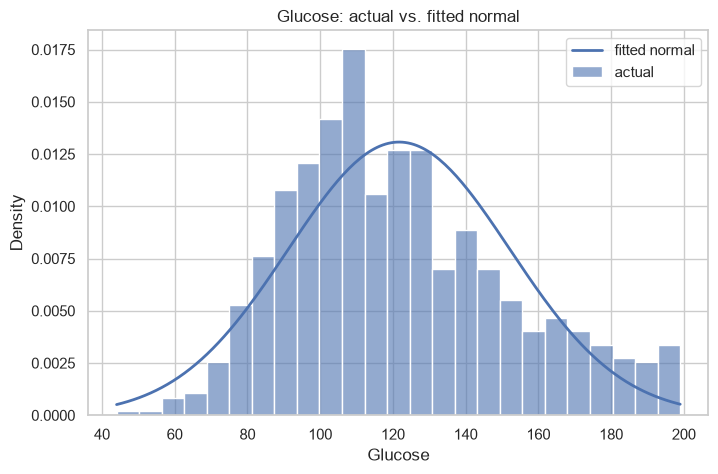

Fitted: mu=121.7, sigma=30.5
Shapiro: statistic=0.9696, p=1.72e-11


In [8]:
glucose = diabetes["Glucose"].dropna()

mu, sigma = stats.norm.fit(glucose)

x = np.linspace(glucose.min(), glucose.max(), 200)
plt.figure(figsize=(8, 5))
sns.histplot(glucose, stat="density", bins=25, alpha=0.6, label="actual")
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="fitted normal", linewidth=2)
plt.legend()
plt.title("Glucose: actual vs. fitted normal")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(glucose)
print(f"Fitted: mu={mu:.1f}, sigma={sigma:.1f}")
print(f"Shapiro: statistic={shapiro_stat:.4f}, p={shapiro_p:.2e}")
# The plot looks close to bell-shaped -- but Shapiro still rejects normality (p is tiny). With 763
# data points, even a small, visually-subtle deviation from normal is enough for the test to catch
# it. "Looks roughly normal" and "is formally normal" are different claims.


### Exercise 1.2 (core) — Fit a Poisson distribution to Pregnancies

`Pregnancies` is a genuine **count** variable — a natural fit for testing a Poisson model. Fit
lambda (just the sample mean, no need to drop anything here — `Pregnancies` has no missing-as-zero
issue, unlike the other columns), plot actual vs. fitted Poisson PMF, and compare the mean to the
variance.

**Why compare mean and variance?** A defining property of a true Poisson distribution is that its
mean *equals* its variance. If the real variance is a lot bigger than the mean, the data is more
spread out than Poisson expects — a pattern called **overdispersion**, and a very common finding in
real count data (Poisson assumes every event is independent and equally likely at every moment,
which is rarely exactly true for something like "number of pregnancies").


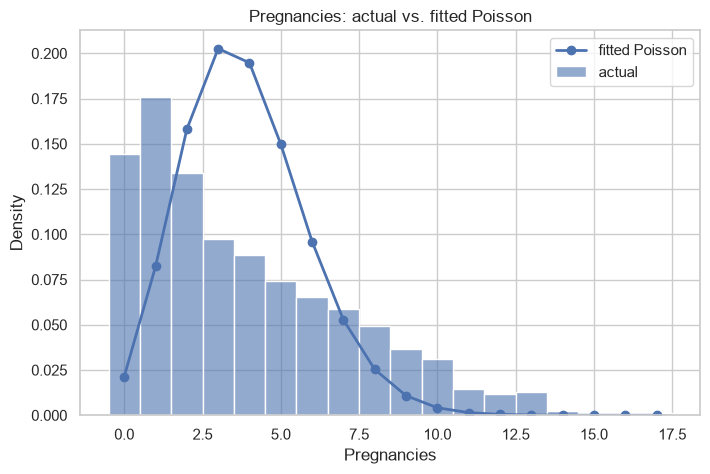

Fitted lambda: 3.85
Mean: 3.85, Variance: 11.35


In [9]:
pregnancies = diabetes["Pregnancies"]

lam = pregnancies.mean()

k = np.arange(0, pregnancies.max() + 1)
plt.figure(figsize=(8, 5))
sns.histplot(
    pregnancies,
    stat="density",
    bins=np.arange(-0.5, pregnancies.max() + 1.5),
    alpha=0.6,
    label="actual",
)
plt.plot(k, stats.poisson.pmf(k, lam), "o-", label="fitted Poisson", linewidth=2)
plt.legend()
plt.title("Pregnancies: actual vs. fitted Poisson")
plt.show()

print(f"Fitted lambda: {lam:.2f}")
print(f"Mean: {pregnancies.mean():.2f}, Variance: {pregnancies.var():.2f}")
# Variance (~11.4) is roughly 3x the mean (~3.8) -- real overdispersion. Number of pregnancies
# varies more across this population than a pure Poisson process would predict, likely because
# "chance of pregnancy" itself differs a lot from woman to woman rather than being one fixed rate.


### Exercise 1.3 (advanced) — Compare distributions

`Insulin` is heavily right-skewed and strictly non-negative (a measurement can't be negative) —
a good candidate for lognormal or gamma instead of normal.

Fit **normal**, **lognormal**, and **gamma** to `Insulin` (dropping missing values — remember,
nearly half of this column is missing), using the frozen-distribution + `kstest` pattern from before.

**Important note**: `Insulin` values cannot be negative so we need to constrain the *floor* for **both** lognormal *and* gamma this time.

In `scipy`, prefixing a fit parameter with `f` tells `.fit()` to hold it fixed rather than estimate it, so
`dist.fit(data, floc=0)` is how you fix the location (floor) at exactly `0`.
<details>
<summary>Try fitting gamma *without* that constraint first, look at the fitted parameters and the resulting KS statistic, then compare against the constrained version.</summary>

You'll likely see something surprising: the *unconstrained* fit is dramatically **worse** (a KS
statistic near 1, essentially a complete rejection), not deceptively better. With `loc` free, the
optimizer can converge to a degenerate solution — when the fitted shape parameter is under 1,
gamma's density spikes sharply as `x` approaches `loc`, so MLE fitting can "cheat" by parking `loc`
right at (or just under) the sample minimum to inflate the likelihood there, at the cost of badly
describing everything else. Constraining `loc=0` — the one value that's actually physically
justified, since `Insulin` can't be negative — avoids this pathology entirely and produces a far
better, sensible fit. The general rule still holds: when you know a hard physical floor, constrain
`loc` to it rather than letting the optimizer wander.
</details>

In [10]:
insulin = diabetes["Insulin"].dropna()

params_unconstrained = stats.gamma.fit(insulin)
frozen_unconstrained = stats.gamma(*params_unconstrained)
ks_unconstrained, p_unconstrained = stats.kstest(insulin, frozen_unconstrained.cdf)
print("Unconstrained gamma params:", params_unconstrained)
print(f"Unconstrained gamma KS: {ks_unconstrained:.3f}, p={p_unconstrained:.2e}")
# The unconstrained fit converges to a degenerate solution: loc lands almost exactly at the
# sample minimum, with a shape parameter well under 1 -- letting the density spike sharply
# right at that edge. KS comes out near 1 (essentially total rejection) -- far worse, not
# better, than the constrained version below. Compare params_unconstrained to the constrained
# gamma fit in the results loop: loc jumps from ~14 (the sample minimum) to the physically
# correct 0, and the fit goes from rejected to plausible.

results = {}
for dist_name in ["norm", "lognorm", "gamma"]:
    dist = getattr(stats, dist_name)
    params = (
        dist.fit(insulin, floc=0)
        if dist_name in ("lognorm", "gamma")
        else dist.fit(insulin)
    )
    frozen = dist(*params)
    ks_stat, p_value = stats.kstest(insulin, frozen.cdf)
    results[dist_name] = {"ks_stat": ks_stat, "p_value": p_value}

for name, res in results.items():
    print(name, res)

best = min(results, key=lambda name: results[name]["ks_stat"])
print("Best fit:", best)
# normal is rejected outright; lognormal (and gamma, once floc=0 is set) are NOT rejected --
# lognormal is typically the closest of the three. A skewed, strictly-positive clinical measurement
# like Insulin is exactly the kind of variable lognormal was built for.


Unconstrained gamma params: (np.float64(0.2643467212597286), np.float64(13.999999999999996), np.float64(2.296446565126833))
Unconstrained gamma KS: 0.984, p=0.00e+00
norm {'ks_stat': np.float64(0.14448752081852567), 'p_value': np.float64(1.2161902459726464e-07)}
lognorm {'ks_stat': np.float64(0.029615294984094653), 'p_value': np.float64(0.8695667503550308)}
gamma {'ks_stat': np.float64(0.057976164743739234), 'p_value': np.float64(0.13601635271774293)}
Best fit: lognorm


## 2. Hypothesis testing

### Exercise 2.1 (core) — t-test: is Glucose different between diabetic and non-diabetic patients?

Split `Glucose` (missing values dropped) by `Outcome`, and run an independent two-sample t-test
(`scipy.stats.ttest_ind`) to check whether the difference in mean glucose is statistically
significant.

Using `alpha = 0.05`: is the difference significant? Given that elevated glucose is literally part
of how diabetes is diagnosed, what result would you *expect* here before running it?


In [11]:
glucose_data = diabetes.dropna(subset=["Glucose"])
g0 = glucose_data.loc[glucose_data["Outcome"] == 0, "Glucose"]
g1 = glucose_data.loc[glucose_data["Outcome"] == 1, "Glucose"]

t_stat, p_value = stats.ttest_ind(g0, g1)

alpha = 0.05
print(f"Non-diabetic mean: {g0.mean():.1f}, Diabetic mean: {g1.mean():.1f}")
print(f"t = {t_stat:.3f}, p = {p_value:.2e}")
print("Significant?", p_value < alpha)
# Extremely significant, as expected -- diabetic patients have meaningfully higher glucose
# readings, which makes physiological sense given how diabetes is diagnosed in the first place.


Non-diabetic mean: 110.6, Diabetic mean: 142.3
t = -15.701, p = 2.48e-48
Significant? True


In [12]:
assert p_value < 0.001
print("Looks good!")


Looks good!


### Exercise 2.2 (core) — Chi-square: is BMI category associated with diabetes?

Bucket `BMI` (missing values dropped) into the standard clinical categories: Underweight (< 18.5),
Normal (18.5–25), Overweight (25–30), Obese (30+) — using `pd.cut`. Build a contingency table of
this category against `Outcome`, and run `scipy.stats.chi2_contingency`.

**Before trusting the result**, check the test's assumption: `chi2_contingency` returns the
*expected* counts as its 4th value. The chi-square test is only reliable when expected counts are
reasonably large (a common rule of thumb: **at least 5** in every cell). Print the expected table —
if any cell is too small, **merge Underweight into Normal** (there are very few underweight patients
in this dataset) and rerun before drawing a conclusion.


In [13]:
bmi_data = diabetes.dropna(subset=["BMI"]).copy()

bins = [0, 18.5, 25, 30, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese"]
bmi_data["bmi_category"] = pd.cut(bmi_data["BMI"], bins=bins, labels=labels)

contingency = pd.crosstab(bmi_data["bmi_category"], bmi_data["Outcome"])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)

print(contingency)
print("Expected counts:\n", expected)
print(f"chi2 = {chi2_stat:.2f}, p = {p_value:.2e}, dof = {dof}")
print("Minimum expected count:", expected.min())
# The Underweight row has an expected count well under 5 (very few underweight patients) --
# the assumption is violated. Merge it into Normal and rerun before trusting the result.

bins_merged = [0, 25, 30, 100]
labels_merged = ["Normal_or_below", "Overweight", "Obese"]
bmi_data["bmi_category_merged"] = pd.cut(
    bmi_data["BMI"], bins=bins_merged, labels=labels_merged
)

contingency_merged = pd.crosstab(bmi_data["bmi_category_merged"], bmi_data["Outcome"])
chi2_stat2, p_value2, dof2, expected2 = stats.chi2_contingency(contingency_merged)

print("\nAfter merging:")
print(contingency_merged)
print("Minimum expected count:", expected2.min())
print(f"chi2 = {chi2_stat2:.2f}, p = {p_value2:.2e}, dof = {dof2}")
# Now every expected count is comfortably above 5, and the conclusion is unchanged: BMI category
# and diabetes outcome are strongly associated.


Outcome         0    1
bmi_category          
Underweight     4    0
Normal        101    7
Overweight    136   44
Obese         250  215
Expected counts:
 [[  2.59445178   1.40554822]
 [ 70.05019815  37.94980185]
 [116.75033025  63.24966975]
 [301.60501982 163.39498018]]
chi2 = 75.24, p = 3.21e-16, dof = 3
Minimum expected count: 1.40554821664465

After merging:
Outcome                0    1
bmi_category_merged          
Normal_or_below      105    7
Overweight           136   44
Obese                250  215
Minimum expected count: 39.3553500660502
chi2 = 75.17, p = 4.75e-17, dof = 2


In [14]:
assert expected2.min() >= 5
assert p_value2 < 0.001
print(
    "Looks good! BMI category and Outcome are significantly associated, now on a valid test."
)


Looks good! BMI category and Outcome are significantly associated, now on a valid test.


### Exercise 2.3 (advanced) — Check normality first, then pick the right test

Write `compare_two_groups(group1, group2, alpha=0.05)`: run `stats.shapiro` on **both** groups;
if both pass (p > alpha), run a t-test; otherwise run `stats.mannwhitneyu`. Return
`{"test_used": ..., "statistic": ..., "p_value": ...}`.

Apply it to `Insulin` split by `Outcome` — you already know from 1.3 that `Insulin` is heavily
skewed, so this is a real test of the branching logic, not a toy case.


In [15]:
def compare_two_groups(group1, group2, alpha=0.05):
    normal1 = stats.shapiro(group1).pvalue > alpha
    normal2 = stats.shapiro(group2).pvalue > alpha

    if normal1 and normal2:
        stat, p_value = stats.ttest_ind(group1, group2)
        test_used = "ttest"
    else:
        stat, p_value = stats.mannwhitneyu(group1, group2)
        test_used = "mannwhitneyu"

    return {"test_used": test_used, "statistic": stat, "p_value": p_value}


insulin_data = diabetes.dropna(subset=["Insulin"])
i0 = insulin_data.loc[insulin_data["Outcome"] == 0, "Insulin"]
i1 = insulin_data.loc[insulin_data["Outcome"] == 1, "Insulin"]

result = compare_two_groups(i0, i1)
print(result)
# Both groups fail normality, so this should have picked "mannwhitneyu" -- and the result is
# highly significant: diabetic and non-diabetic patients have meaningfully different insulin levels.


{'test_used': 'mannwhitneyu', 'statistic': np.float64(9210.5), 'p_value': np.float64(7.476985712790264e-14)}


## 3. Correlation & optimization

### Exercise 3.1 (core) — Pearson correlation, with significance

Compute the Pearson correlation (`scipy.stats.pearsonr`) between:
1. `Age` and `Pregnancies`
2. `Glucose` and `BMI`

(Drop missing values pairwise for each pair — `.dropna()` on just the two columns involved, since
different columns have different missing patterns.)

Both should come back statistically significant given how much data we have — but look closely at
the **size** of `r` in each case, not just the p-value. A relationship can be statistically
significant (real, not noise) while still being practically weak. With a large enough sample, even
a small, not-very-useful correlation can produce a tiny p-value.


In [16]:
pair1 = diabetes[["Age", "Pregnancies"]].dropna()
r1, p1 = stats.pearsonr(pair1["Age"], pair1["Pregnancies"])

pair2 = diabetes[["Glucose", "BMI"]].dropna()
r2, p2 = stats.pearsonr(pair2["Glucose"], pair2["BMI"])

print(f"Age vs Pregnancies: r={r1:.3f}, p={p1:.2e}, n={len(pair1)}")
print(f"Glucose vs BMI:     r={r2:.3f}, p={p2:.2e}, n={len(pair2)}")
# Age/Pregnancies: a genuinely strong, intuitive relationship (older women have had more time to
# have had pregnancies). Glucose/BMI: also significant, but r is much smaller -- a real but modest
# relationship. Both p-values are tiny, but they're answering "is this relationship real?", not
# "is this relationship strong?" -- r answers the second question.


Age vs Pregnancies: r=0.544, p=1.86e-60, n=768
Glucose vs BMI:     r=0.233, p=1.04e-10, n=752


### Exercise 3.2 (core) — Spearman as a robustness check

Recompute both pairs from 3.1 using **Spearman's rank correlation**. Spearman only cares about
monotonic relationships and is less sensitive to outliers than Pearson — a useful cross-check
whenever a relationship might not be perfectly linear.


In [17]:
rho1, sp1 = stats.spearmanr(pair1["Age"], pair1["Pregnancies"])
rho2, sp2 = stats.spearmanr(pair2["Glucose"], pair2["BMI"])

print(f"Age vs Pregnancies: rho={rho1:.3f}, p={sp1:.2e}")
print(f"Glucose vs BMI:     rho={rho2:.3f}, p={sp2:.2e}")


Age vs Pregnancies: rho=0.607, p=1.45e-78
Glucose vs BMI:     rho=0.228, p=2.64e-10


### Exercise 3.3 (core) — Minimize a cost function

A clinic orders glucose test strips in batches. Larger batches mean fewer orders (lower ordering
cost) but more strips sitting in storage at once (higher holding cost). Given:

```
total_cost(x) = 8000 / x + 1.5 * x
```

where `x` is the batch size, find the `x` that **minimizes** total cost, using
`scipy.optimize.minimize_scalar` with `bounds=(1, 10000)` and `method="bounded"`.


In [18]:
def total_cost(x):
    return 8000 / x + 1.5 * x


result = optimize.minimize_scalar(total_cost, bounds=(1, 10000), method="bounded")

print(f"Optimal batch size: {result.x:.1f}, minimum cost: {result.fun:.1f}")


Optimal batch size: 73.0, minimum cost: 219.1


In [19]:
assert abs(result.x - 73.03) < 1
print("Looks good!")


Looks good!


### Exercise 3.4 (advanced) — Multi-variable optimization with a constraint

A public health department has a $100,000 outreach budget (in $1000 units, `x + y = 100`) to split
between two diabetes-screening programs, each with **diminishing returns** (more funding helps, but
with less extra benefit each time):

```
expected_screenings(x, y) = 5*x - 0.03*x^2 + 8*y - 0.02*y^2
```

Find the split `(x, y)` that **maximizes** expected screenings, subject to `x + y = 100` and
`x, y >= 0`, using `scipy.optimize.minimize` (minimize the *negative*), `method="SLSQP"`, an
equality constraint, and bounds.


In [20]:
def neg_expected_screenings(vars):
    x, y = vars
    return -(5 * x - 0.03 * x**2 + 8 * y - 0.02 * y**2)


constraints = ({"type": "eq", "fun": lambda v: v[0] + v[1] - 100},)
bounds = [(0, 100), (0, 100)]

result = optimize.minimize(
    neg_expected_screenings,
    x0=[50, 50],
    bounds=bounds,
    constraints=constraints,
    method="SLSQP",
)

print(f"Optimal split: program A = {result.x[0]:.1f}, program B = {result.x[1]:.1f}")
print(f"Expected screenings: {-result.fun:.1f}")


Optimal split: program A = 10.0, program B = 90.0
Expected screenings: 605.0


## 4. Finishing `EDAReport`

**New dataset for this part**: the real Olist e-commerce data from Session 2 -- delivered orders
only, converted to EUR using the real historical BRL/EUR rates. This is the dataset `EDAReport`
keeps growing on going forward; Sections 1-3 used the diabetes dataset specifically for its clean,
well-known stats teaching properties, but this class's real home is the running business dataset.

Rebuild the merge from Session 2 (same five files, same steps): merge orders with items, filter to
delivered, attach English category names, derive a month key, merge in the FX rate, and compute
`price_eur`. This is a recap of work already done, not a new exercise -- just run the cell below.

Bring your finished `EDAReport` class from Session 2 into the cell below, or use the version
provided here as a starting point.


In [21]:
orders = pd.read_csv("olist_orders.csv", parse_dates=["order_purchase_timestamp"])
order_items = pd.read_csv("olist_order_items.csv")
products = pd.read_csv("olist_products.csv")
category_translation = pd.read_csv("product_category_translation.csv")
fx_olist = pd.read_csv("brl_eur_rates.csv", parse_dates=["date"]).rename(
    columns={"date": "month"}
)

products_en = pd.merge(
    products, category_translation, on="product_category_name", how="left"
)
delivered = pd.merge(order_items, orders, on="order_id", how="left")
delivered = delivered[delivered["order_status"] == "delivered"].copy()

olist = pd.merge(delivered, products_en, on="product_id", how="left")
olist["month"] = olist["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
olist = pd.merge(olist, fx_olist, on="month", how="left")
olist["price_eur"] = olist["price"] * olist["rate"]

print(olist.shape)
print(olist["rate"].isna().sum())  # should be 0
olist[
    ["order_id", "product_category_name_english", "price", "freight_value", "price_eur"]
].head()


FileNotFoundError: [Errno 2] No such file or directory: 'olist_orders.csv'

### Exercise 4.1 (core) -- `test_normality`

Add a method `test_normality(self, column, alpha=0.05)` that runs `stats.shapiro` on a column
(dropping missing values first) and returns `{"statistic": ..., "p_value": ..., "is_normal": ...}`.

**One real wrinkle**: `olist` has over 100,000 rows, and scipy will warn that Shapiro's p-value
"may not be accurate" above n=5000. That's a genuine limitation of the test, not something to
paper over -- run it anyway (the warning doesn't stop it from working), but keep in mind for any
very large dataset that Shapiro was never designed with sample sizes like this in mind.


In [ ]:
class EDAReport:
    def __init__(self, df):
        self.df = df

    def summary(self):
        return {
            "n_rows": self.df.shape[0],
            "columns": list(self.df.columns),
            "missing": self.df.isna().sum().to_dict(),
        }

    def plot_distributions(self, columns=None):
        if columns is None:
            columns = self.df.select_dtypes(include="number").columns
        for col in columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(self.df[col].dropna(), kde=True)
            plt.title(f"Distribution of {col}")
            plt.show()

    def correlation_heatmap(self):
        numeric_df = self.df.select_dtypes(include="number")
        plt.figure(figsize=(7, 6))
        sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
        plt.title("Correlation heatmap")
        plt.show()

    def detect_outliers(self, method="iqr"):
        masks = {}
        for col in self.df.select_dtypes(include="number").columns:
            series = self.df[col]
            if method == "iqr":
                q1, q3 = series.quantile(0.25), series.quantile(0.75)
                iqr = q3 - q1
                lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                mask = (series < lower) | (series > upper)
            elif method == "zscore":
                z_scores = (series - series.mean()) / series.std()
                mask = z_scores.abs() > 3
            else:
                raise ValueError(f"Unknown method: {method!r}")
            masks[col] = mask.fillna(False)
        return masks


print("Starting point loaded -- extend this class in the exercises below.")


In [ ]:
class EDAReport(EDAReport):
    # ... (previous methods unchanged: summary, plot_distributions, correlation_heatmap,
    #      detect_outliers -- see the starting point above)

    def test_normality(self, column, alpha=0.05):
        stat, p_value = stats.shapiro(self.df[column].dropna())
        return {"statistic": stat, "p_value": p_value, "is_normal": p_value > alpha}


report = EDAReport(olist)
print(report.test_normality("price_eur"))
# Unsurprising given what Session 3's earlier sections taught: item prices are heavily right-skewed
# (a floor near zero, a long tail of expensive items), so normality is rejected here too.


In [ ]:
result = report.test_normality("price_eur")
assert set(result.keys()) == {"statistic", "p_value", "is_normal"}
assert result["is_normal"] == False
print("Looks good!")


### Exercise 4.2 (core) -- `compare_groups`

Add a method `compare_groups(self, column, group_col)` that drops missing values in `column`,
splits into exactly two groups by `group_col`, runs a t-test, and returns
`{"groups": [...], "statistic": ..., "p_value": ...}`. (We'll upgrade this to auto-select the test
in Exercise 4.4 -- keep it simple here.)

Try it on the two best-selling categories, `health_beauty` and `sports_leisure`, comparing
`price_eur`.


In [ ]:
two_categories = olist[
    olist["product_category_name_english"].isin(["health_beauty", "sports_leisure"])
]


class EDAReport(EDAReport):
    # ... (previous methods unchanged)

    def compare_groups(self, column, group_col):
        data = self.df.dropna(subset=[column])
        groups = data[group_col].unique()
        if len(groups) != 2:
            raise ValueError(
                f"compare_groups expects exactly 2 groups, got {len(groups)}"
            )
        g1 = data.loc[data[group_col] == groups[0], column]
        g2 = data.loc[data[group_col] == groups[1], column]
        stat, p_value = stats.ttest_ind(g1, g2)
        return {"groups": list(groups), "statistic": stat, "p_value": p_value}


report = EDAReport(two_categories)
print(report.compare_groups("price_eur", "product_category_name_english"))
# Extremely significant by t-test (p on the order of 1e-8) -- but hold that thought for Exercise 4.4.


### Exercise 4.3 (core) -- `correlation_significance`

Add a method `correlation_significance(self)` that computes the **Pearson** correlation and p-value
between every pair of numeric columns (dropping missing values pairwise per pair), returning a
DataFrame with columns `col1`, `col2`, `r`, `p_value`.


In [ ]:
from itertools import combinations


class EDAReport(EDAReport):
    # ... (previous methods unchanged)

    def correlation_significance(self):
        numeric_cols = self.df.select_dtypes(include="number").columns
        rows = []
        for col1, col2 in combinations(numeric_cols, 2):
            pair = self.df[[col1, col2]].dropna()
            r, p_value = stats.pearsonr(pair[col1], pair[col2])
            rows.append({"col1": col1, "col2": col2, "r": r, "p_value": p_value})
        return pd.DataFrame(rows)


report = EDAReport(olist)
print(report.correlation_significance())
# price vs freight_value: r is moderate but real (~0.41) -- pricier items cost more to ship, but
# it's far from a strict rule. price vs price_eur: r is close to 1 (~0.99) -- expected, since the
# FX rate only varies month to month while price varies item to item, so the two track each other
# almost exactly.


In [ ]:
corr_sig = report.correlation_significance()
assert set(corr_sig.columns) == {"col1", "col2", "r", "p_value"}
assert len(corr_sig) > 0
print("Looks good!")


### Exercise 4.4 (advanced) -- Auto-selecting `compare_groups`

Upgrade `compare_groups` to check normality of both groups first (reuse `test_normality` on each
group's own data), and branch to `ttest_ind` if both pass, or `mannwhitneyu` otherwise -- the
pattern from Exercise 2.3, now living inside the class. Add `"test_used"` to the returned dict.

Rerun the `health_beauty` vs. `sports_leisure` comparison from 4.2 with this version, and compare
the p-value to what the plain t-test gave you. They should look very different -- that difference
*is* the point of this exercise, not a bug to explain away.


In [ ]:
class EDAReportV2(EDAReport):
    def compare_groups(self, column, group_col, alpha=0.05):
        data = self.df.dropna(subset=[column])
        groups = data[group_col].unique()
        if len(groups) != 2:
            raise ValueError(
                f"compare_groups expects exactly 2 groups, got {len(groups)}"
            )
        g1 = data.loc[data[group_col] == groups[0], column]
        g2 = data.loc[data[group_col] == groups[1], column]

        normal1 = stats.shapiro(g1).pvalue > alpha
        normal2 = stats.shapiro(g2).pvalue > alpha

        if normal1 and normal2:
            stat, p_value = stats.ttest_ind(g1, g2)
            test_used = "ttest"
        else:
            stat, p_value = stats.mannwhitneyu(g1, g2)
            test_used = "mannwhitneyu"

        return {
            "groups": list(groups),
            "statistic": stat,
            "p_value": p_value,
            "test_used": test_used,
        }


report2 = EDAReportV2(two_categories)
print(report2.compare_groups("price_eur", "product_category_name_english"))
# test_used should be "mannwhitneyu" -- both categories' prices are heavily skewed.
#
# The real punchline: the plain t-test in 4.2 gave an astronomically small p-value (p ~ 1e-8) --
# looked like an unmistakable difference. Mann-Whitney gives roughly p ~ 0.06 on the exact same
# data -- not significant at the usual 0.05 threshold. The medians of the two groups are almost
# identical (~19.8 EUR each); the means differ more because health_beauty has a heavier tail of
# expensive items pulling its mean up. The t-test compares means, which a handful of very expensive
# items can drag around; Mann-Whitney compares ranks, which barely notice those same items. Neither
# test is "wrong" -- but only one of them is really answering "is the *typical* item priced
# differently here?", and picking whichever test gives the answer you like, after the fact, is
# exactly the mistake this whole normality-check-first habit exists to prevent.


In [ ]:
result2 = report2.compare_groups("price_eur", "product_category_name_english")
assert result2["test_used"] == "mannwhitneyu"
print("Looks good!")


### Exercise 4.5 (core) -- `generate_report()`

Add a method `generate_report(self)` that calls, in order: `summary()` (print it),
`plot_distributions()`, `correlation_heatmap()`, and `detect_outliers()` (print counts per column).


In [ ]:
class EDAReportV3(EDAReportV2):
    def generate_report(self):
        print("=== Summary ===")
        print(self.summary())
        print("\n=== Distributions ===")
        self.plot_distributions()
        print("\n=== Correlation heatmap ===")
        self.correlation_heatmap()
        print("\n=== Outliers (IQR) ===")
        outliers = self.detect_outliers()
        print({col: int(mask.sum()) for col, mask in outliers.items()})


report3 = EDAReportV3(olist)
report3.generate_report()


### Exercise 4.6 (advanced) -- Exportable `generate_report()`

Add `generate_report(self, export_dir=None)`: `None` behaves like 4.5 (inline); otherwise, create
the directory, save each distribution plot and the correlation heatmap as `.png` files
(`plt.savefig(...)` **before** `plt.show()`), and write a `summary.md` with the summary dict and
outlier counts as readable text.


In [ ]:
import os


class EDAReportV4(EDAReportV3):
    def generate_report(self, export_dir=None):
        if export_dir is None:
            super().generate_report()
            return

        os.makedirs(export_dir, exist_ok=True)

        numeric_cols = self.df.select_dtypes(include="number").columns
        for col in numeric_cols:
            plt.figure(figsize=(6, 4))
            sns.histplot(self.df[col].dropna(), kde=True)
            plt.title(f"Distribution of {col}")
            plt.savefig(os.path.join(export_dir, f"dist_{col}.png"))
            plt.show()

        plt.figure(figsize=(7, 6))
        sns.heatmap(
            self.df[numeric_cols].corr(),
            annot=True,
            cmap="coolwarm",
            center=0,
            fmt=".2f",
        )
        plt.title("Correlation heatmap")
        plt.savefig(os.path.join(export_dir, "correlation_heatmap.png"))
        plt.show()

        outliers = self.detect_outliers()
        summary = self.summary()

        with open(os.path.join(export_dir, "summary.md"), "w") as f:
            f.write(
                "# EDA Report -- Olist Brazilian E-Commerce (delivered orders, EUR-converted)\n\n"
            )
            f.write(f"- Rows: {summary['n_rows']}\n")
            f.write(f"- Columns: {summary['columns']}\n\n")
            f.write("## Missing values\n")
            for col, count in summary["missing"].items():
                f.write(f"- {col}: {count}\n")
            f.write("\n## Outliers (IQR method)\n")
            for col, mask in outliers.items():
                f.write(f"- {col}: {int(mask.sum())}\n")


report4 = EDAReportV4(olist)
report4.generate_report(export_dir="eda_report_output")
print(os.listdir("eda_report_output"))


In [ ]:
import os

assert os.path.exists("eda_report_output/summary.md")
assert any(f.startswith("dist_") for f in os.listdir("eda_report_output"))
print("Looks good!")


## 5. Mini-project -- put it all together

Using `EDAReportV4` (or whichever version you built), run a small end-to-end analysis on `olist`:

1. Call `generate_report()` inline (no `export_dir`) and read through the output.
2. Pick two more categories from `olist["product_category_name_english"].value_counts()` and use
   the **auto-selecting** `compare_groups` to test whether `price_eur` differs significantly
   between them -- state your conclusion in a comment, and note which test got picked.
3. Using `correlation_significance()`, find the pair of numeric columns with the **strongest**
   significant correlation (smallest p-value among pairs where `p_value < 0.05`) -- and separately,
   check whether that pair also has a *large* `r`, given what you saw in Exercise 4.3 about
   significance and strength not being the same thing.
4. Export the full report to a folder called `final_report` and confirm the files exist.

This is intentionally open-ended -- there's no single "correct" set of observations for step 1.
The point is exercising the full class, end to end, on real data -- exactly what `EDAReport` was
built for across these three sessions.


In [ ]:
final_report = EDAReportV4(olist)

# 1. Full inline report
final_report.generate_report()

# 2. Compare two more categories
print(olist["product_category_name_english"].value_counts().head(10))
pair = olist[
    olist["product_category_name_english"].isin(
        ["computers_accessories", "bed_bath_table"]
    )
]
pair_report = EDAReportV2(pair)
result = pair_report.compare_groups("price_eur", "product_category_name_english")
print(result)
# Conclusion: state whichever way the numbers actually come out, and note the "test_used" value --
# that's the whole point of building the auto-selecting version.

# 3. Strongest significant correlation
corr_sig = final_report.correlation_significance()
significant = corr_sig[corr_sig["p_value"] < 0.05]
strongest = significant.loc[significant["r"].abs().idxmax()]
print(strongest)

# 4. Export
final_report.generate_report(export_dir="final_report")
import os

print(os.listdir("final_report"))


---

**That's the full arc**: a list-of-dicts class that could only compute a shape and count missing
values in Session 1, now a full pandas + seaborn + scipy analysis tool that cleans real data, fits
distributions, runs the right hypothesis test automatically, and exports a shareable report -- built
up exercise by exercise across three sessions. Today it ran on two different real datasets: the
diabetes data for learning the statistical techniques cleanly, and the Olist e-commerce data --
the one it kept growing on -- for applying them where the answer wasn't already known.
